In [3]:
# ===================== ALL-IN-ONE: 3D simplex (tetrahedra) for PID-SP =====================
# Requirements: pyomo, gurobi, numpy, scipy, plotly, tqdm, csv file "data.csv"
# -----------------------------------------------------------------------------------------

import numpy as np
import itertools as it
import csv
from tqdm import tqdm
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition
from scipy.spatial import Delaunay
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# ------------------------- Config knobs -------------------------
MIN_DIST   = 1e-8     # 去重阈值
ACTIVE_TOL = 1e-8     # active 判定容差
MS_AGG     = "sum"    # 单形 ms 聚合：'sum' 或 'mean'

# ------------------------- Level-set shrink on active tetrahedra -------------------------
SHRINK_REL_EPS = 1e-6   # 相对 eps：UB 的相对抬升量
SHRINK_ABS_EPS = 1e-9   # 绝对 eps：UB 的绝对抬升量（避免 UB=0 时失效）

def shrink_active_tetra_by_levelset(per_tet, UB_global, nodes, scen_values,
                                    model_list, first_vars_list, solver,
                                    min_dist=MIN_DIST, active_mask=None, verbose=True):
    """
    对 active 单形执行“按 As 的 UB+eps 等值线切边”的收缩。
    需要访问 model_list / first_vars_list / solver 来在新点上评估各场景真实值。
    """
    if active_mask is None:
        active_mask = {r["simplex_index"]: True for r in per_tet}

    level = UB_global + max(SHRINK_ABS_EPS, abs(UB_global) * SHRINK_REL_EPS)
    tet_edges = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]

    S = len(model_list)
    added_points = []
    shrunk_tets = 0

    for r in per_tet:
        sid = r["simplex_index"]
        if not active_mask.get(sid, False):
            continue

        ms_total = float(r["ms"])
        f_sum_verts = r["fverts_sum"]  # 长度4
        val4 = [float(f_sum_verts[j]) + ms_total for j in range(4)]

        verts = np.asarray(r["verts"], dtype=float)
        added_here = 0

        for (a, b) in tet_edges:
            va, vb = verts[a], verts[b]
            fa, fb = val4[a], val4[b]

            da = fa - level
            db = fb - level
            if da == 0 and db == 0:
                continue
            if da * db > 0:
                continue

            denom = fb - fa
            if abs(denom) < 1e-15:
                continue
            t = (level - fa) / denom
            if t <= 1e-12 or t >= 1 - 1e-12:
                continue

            p = (1.0 - t) * va + t * vb
            p = tuple(map(float, p))
            if too_close(p, nodes, tol=min_dist):
                continue

            # 评估 S 个场景真实值
            new_vals = []
            for ω in range(S):
                val = evaluate_Q_at(model_list[ω], first_vars_list[ω], p, solver)
                new_vals.append(val)

            nodes.append(p)
            for ω in range(S):
                scen_values[ω].append(new_vals[ω])

            added_points.append(p)
            added_here += 1

        if added_here > 0:
            shrunk_tets += 1

    if verbose:
        print(f"[shrink] shrunk {shrunk_tets} simplices, added {len(added_points)} nodes (level=UB+eps).")

    return len(added_points), shrunk_tets



# ------------------------- PID scenario model -------------------------
def build_pid_model(T=10, h=0.2, scen=None, weights=(1.0, 0.01),
                    bounds=None, use_cvar=False, alpha=0.95):
    assert scen is not None, "请提供一个场景字典"
    Ku, tau, d, sp = scen["Ku"], scen["tau"], scen["d"], scen["sp"]
    assert len(d) == T+1 and len(sp) == T+1

    if bounds is None:
        bounds = {}
    bx = bounds.get("x",  (-20, 20))
    bu = bounds.get("u",  (None, None))
    bKp= bounds.get("Kp", (0, 10))
    bKi= bounds.get("Ki", (0, 10))
    bKd= bounds.get("Kd", (0, 10))
    be = bounds.get("e",  (-100, 100))
    bI = bounds.get("I",  (-200, 200))

    m = pyo.ConcreteModel()
    m.T  = pyo.RangeSet(0, T)
    m.Tm = pyo.RangeSet(1, T)

    m.Kp = pyo.Var(bounds=bKp)
    m.Ki = pyo.Var(bounds=bKi)
    m.Kd = pyo.Var(bounds=bKd)

    m.x = pyo.Var(m.T, bounds=bx)
    m.u = pyo.Var(m.T, bounds=bu)
    m.e = pyo.Var(m.T, bounds=be)
    m.I = pyo.Var(m.T, bounds=bI)

    # error
    def _err_rule(m, t): return m.e[t] == sp[t] - m.x[t]
    m.err_def = pyo.Constraint(m.T, rule=_err_rule)

    # integral
    def _I_dyn(m, t): return m.I[t] == m.I[t-1] + h*m.e[t]
    m.I_dyn = pyo.Constraint(m.Tm, rule=_I_dyn)

    # plant
    def _x_dyn(m, t):
        return m.x[t] == m.x[t-1] + (h/tau)*(-m.x[t] + Ku*m.u[t] + d[t])
    m.x_dyn = pyo.Constraint(m.Tm, rule=_x_dyn)

    # pid
    def _pid_rule(m, t):
        if t == 0:
            return m.u[t] == m.Kp*m.e[t] + m.Ki*m.I[t]
        return m.u[t] == m.Kp*m.e[t] + m.Ki*m.I[t] + m.Kd*(m.e[t]-m.e[t-1])/h
    m.pid = pyo.Constraint(m.T, rule=_pid_rule)

    m.x0 = pyo.Constraint(expr=m.x[0] == 0)
    m.I0 = pyo.Constraint(expr=m.I[0] == 0)

    w_e, w_u = weights
    m.cost = pyo.Expression(expr=sum(h*(w_e*m.e[t]**2 + w_u*m.u[t]**2) for t in m.T))
    m.obj_expr = pyo.Expression(expr=m.cost)
    return m, [m.Kp, m.Ki, m.Kd]

def load_scenarios_from_csv(csv_path: str, T: int | None = None,
                            sp0: float = 0.0, sp1: float = 0.5,
                            ku_col: str = "tau_us", tau_col: str = "tau_xs",
                            disturb_prefix: str = "disturbance_",
                            setpoint_change_col: str = "setpoint_change"):
    scens = []
    # 推断 T
    if T is None:
        with open(csv_path, "r", newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            fields  = reader.fieldnames or []
            max_idx = -1
            for name in fields:
                if name.startswith(disturb_prefix):
                    try:
                        k = int(name[len(disturb_prefix):])
                        max_idx = max(max_idx, k)
                    except:
                        pass
            if max_idx < 0:
                raise ValueError(f"未找到扰动列前缀 {disturb_prefix}k")
            T = max_idx

    with open(csv_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            Ku  = float(row[ku_col])
            tau = float(row[tau_col])

            d = []
            for t in range(T+1):
                col = f"{disturb_prefix}{t}"
                d.append(float(row[col]))

            sp = [sp1]*(T+1)
            if setpoint_change_col in row and row[setpoint_change_col] != "":
                try:
                    t_star = int(float(row[setpoint_change_col]))
                    for t in range(T+1):
                        sp[t] = sp0 if t < t_star else sp1
                except:
                    pass

            scens.append({"Ku": Ku, "tau": tau, "d": d, "sp": sp})
    return scens, T

def build_models_from_csv(csv_path: str, h: float = 0.2,
                          weights=(1.0, 0.01), bounds=None,
                          sp0: float = 0.0, sp1: float = 0.5,
                          ku_col: str = "tau_us", tau_col: str = "tau_xs",
                          disturb_prefix: str = "disturbance_",
                          setpoint_change_col: str = "setpoint_change",
                          max_scenarios=None, skip=0):
    scens, T = load_scenarios_from_csv(
        csv_path=csv_path, T=None, sp0=sp0, sp1=sp1,
        ku_col=ku_col, tau_col=tau_col,
        disturb_prefix=disturb_prefix, setpoint_change_col=setpoint_change_col,
    )
    if skip or max_scenarios:
        scens = scens[skip: (skip + max_scenarios) if max_scenarios else None]

    model_list, first_stg_vars_list = [], []
    for scen in scens:
        m, yvars = build_pid_model(T=T, h=h, scen=scen, weights=weights, bounds=bounds)
        model_list.append(m)
        first_stg_vars_list.append(yvars)

    m_tmpl_list = [model_list[0], first_stg_vars_list[0]]
    return model_list, first_stg_vars_list, m_tmpl_list, T

# ------------------------- Basic utils -------------------------
def corners_from_var_bounds(vars_3):
    bnds = []
    for v in vars_3:
        lb, ub = v.lb, v.ub
        if lb is None or ub is None:
            raise ValueError(f"{v.name} 缺少上下界")
        bnds.append((float(lb), float(ub)))
    return [tuple(p) for p in it.product(*[(lo, hi) for (lo,hi) in bnds])]

def too_close(p, nodes, tol=MIN_DIST):
    return any(np.linalg.norm(np.asarray(p)-np.asarray(q)) < tol for q in nodes)

def evaluate_Q_at(model, first_stg_vars, first_stg_vals, solver):
    """把 Kp,Ki,Kd 固定为给定值，最小化 obj_expr，返回该场景下的真实目标值（用 Gurobi 解）。"""
    # 清理旧目标
    if hasattr(model, 'obj'):
        model.del_component('obj')
    # 固定变量
    for u, v in zip(first_stg_vars, first_stg_vals):
        u.fix(float(v))
    model.obj = pyo.Objective(expr=model.obj_expr, sense=pyo.minimize)
    try:
        results = solver.solve(model, tee=False)
        ok = (results.solver.status == SolverStatus.ok) and \
             (results.solver.termination_condition == TerminationCondition.optimal)
        if not ok:
            raise RuntimeError(f"evaluate_Q_at not optimal: {results.solver.status}, {results.solver.termination_condition}")
        return float(pyo.value(model.obj_expr))
    finally:
        # 清理+解锁
        if hasattr(model, 'obj'):
            model.del_component('obj')
        for u in first_stg_vars:
            if u.fixed:
                u.unfix()

# ------------------------- Single tetra & scene: ms solve -------------------------
def ms_on_tetra_for_scene(model_tmpl, first_vars, solver, tet_vertices, fverts_scene):
    """
    在一个四面体（四个顶点 tet_vertices）上，对单个场景：
      ms = min_{lambda>=0, 1^T lambda=1} [ obj_expr(K(lambda)) - sum_j lambda_j f(v_j) ]
    其中 K(lambda) = sum_j lambda_j * v_j， f(v_j) 是该场景在顶点 v_j 的真实值（已给）。
    返回 (ms_value, lambda*, new_point)；若失败返回 (inf, None, None)
    """
    m = model_tmpl.clone()

    # 取 Kp,Ki,Kd
    Kp = m.find_component(first_vars[0].name)
    Ki = m.find_component(first_vars[1].name)
    Kd = m.find_component(first_vars[2].name)
    if any(v is None for v in (Kp,Ki,Kd)):
        raise RuntimeError("克隆模型中找不到 Kp/Ki/Kd")

    # 重心变量
    m.lam = pyo.Var(range(4), domain=pyo.NonNegativeReals)
    m.lam_sum = pyo.Constraint(expr=sum(m.lam[j] for j in range(4)) == 1.0)

    vx = [float(tet_vertices[j][0]) for j in range(4)]
    vy = [float(tet_vertices[j][1]) for j in range(4)]
    vz = [float(tet_vertices[j][2]) for j in range(4)]
    m.link_kp = pyo.Constraint(expr=Kp == sum(m.lam[j]*vx[j] for j in range(4)))
    m.link_ki = pyo.Constraint(expr=Ki == sum(m.lam[j]*vy[j] for j in range(4)))
    m.link_kd = pyo.Constraint(expr=Kd == sum(m.lam[j]*vz[j] for j in range(4)))

    # As（该场景）
    m.As = pyo.Var()
    m.As_def = pyo.Constraint(expr=m.As == sum(m.lam[j]*float(fverts_scene[j]) for j in range(4)))

    if hasattr(m, 'obj'): m.del_component('obj')
    m.obj = pyo.Objective(expr=m.obj_expr - m.As, sense=pyo.minimize)

    res = solver.solve(m, tee=False)
    ok = (res.solver.status == SolverStatus.ok) and \
         (res.solver.termination_condition == TerminationCondition.optimal)
    if not ok:
        return float('inf'), None, None

    ms_val = float(pyo.value(m.obj))
    lam_star = np.array([pyo.value(m.lam[j]) for j in range(4)], dtype=float)
    new_pt = np.dot(lam_star, np.array(tet_vertices, dtype=float))
    return ms_val, lam_star, tuple(map(float, new_pt))

# ------------------------- Evaluate all tetrahedra -------------------------
def evaluate_all_tetra(nodes, scen_values, model_list, first_vars_list, solver):
    """
    nodes           : 当前节点列表（3D 点）
    scen_values     : 形状 S×len(nodes)，每个场景在每个节点上的真实值
    返回 tri, per_tet； per_tet 每项含：
      'simplex_index','vert_idx','verts','fverts_sum','ms_per_scene','ms','LB','UB','x_ms_best_scene','best_scene'
    """
    pts = np.asarray(nodes, dtype=float)
    if len(pts) < 4:
        return None, []
    tri = Delaunay(pts)  # simplices: (M,4)
    S = len(model_list)

    per_tet = []
    for k, simp in enumerate(tri.simplices):
        idxs = list(map(int, simp))
        verts = [tuple(pts[i]) for i in idxs]
        # 各场景四顶点值
        fverts_per_scene = [[scen_values[ω][i] for i in idxs] for ω in range(S)]
        # “总 f” 顶点（用于 min/max）
        fverts_sum = [sum(fverts_per_scene[ω][j] for ω in range(S)) for j in range(4)]

        ms_scene = []
        xms_scene = []
        for ω in range(S):
            ms_val, lam_star, new_pt = ms_on_tetra_for_scene(
                model_list[ω], first_vars_list[ω], solver, verts, fverts_per_scene[ω]
            )
            ms_scene.append(ms_val)
            xms_scene.append(new_pt)

        if MS_AGG == "sum":
            ms_total = float(np.sum(ms_scene))
        elif MS_AGG == "mean":
            ms_total = float(np.mean(ms_scene))
        else:
            raise ValueError("MS_AGG must be 'sum' or 'mean'")

        LB = float(np.min(fverts_sum) + ms_total)
        UB = float(np.max(fverts_sum) + ms_total)

        best_scene = int(np.argmin(ms_scene))
        x_ms_best = xms_scene[best_scene]

        per_tet.append({
            "simplex_index": k,
            "vert_idx": idxs,
            "verts": verts,
            "fverts_sum": fverts_sum,
            "ms_per_scene": ms_scene,
            "ms": ms_total,
            "LB": LB,
            "UB": UB,
            "x_ms_best_scene": x_ms_best,
            "best_scene": best_scene,
        })

    return tri, per_tet

# ------------------------- Pretty print -------------------------
def print_tetra_table(per_tet, active_mask, purple_set=None, prec=6):
    purple_set = set() if purple_set is None else set(purple_set)
    per_tet = sorted(per_tet, key=lambda r: r["simplex_index"])
    tet_ids = [r["simplex_index"] for r in per_tet]
    active_set = {tid for tid in tet_ids if active_mask.get(tid, False)}

    # 表头：active 加 *，包含最小点加 ^（两者都有 → *^）
    def _mark(tid):
        s = f"T{tid}"
        flags = []
        if tid in active_set:  flags.append("*")
        if tid in purple_set:  flags.append("^")
        return s + ("".join(flags) if flags else "")

    header = ["row\\simp"] + [_mark(tid) for tid in tet_ids]
    rows = [
        ["UB"] + [f"{r['UB']:.{prec}f}" for r in per_tet],
        ["LB"] + [f"{r['LB']:.{prec}f}" for r in per_tet],
        ["ms"] + [f"{r['ms']:.3e}"       for r in per_tet],
    ]

    # 计算列宽
    table = [header] + rows
    colw = [max(len(str(row[c])) for row in table) + 2 for c in range(len(header))]

    # 颜色：active=红；包含最小点=紫；若两者都中，紫优先
    RED, PURPLE, RESET = "\033[31m", "\033[35m", "\033[0m"
    def colorize(col_idx, s):
        if col_idx == 0:
            return s
        tid = tet_ids[col_idx-1]
        if tid in purple_set:
            return f"{PURPLE}{s}{RESET}"
        elif tid in active_set:
            return f"{RED}{s}{RESET}"
        return s

    print("\n== Per-tetra summary ==")
    print("".join(colorize(c, str(header[c]).ljust(colw[c])) for c in range(len(header))))
    print("-"*sum(colw))
    for r in rows:
        line = []
        for c in range(len(header)):
            cell = str(r[c])
            pad  = cell.ljust(colw[c]) if c==0 else cell.rjust(colw[c])
            line.append(colorize(c, pad))
        print("".join(line))
    print("(红色列=active；紫色列=包含当前最小节点的单形；第1行=UB，第2行=LB，第3行=ms)\n")


def print_per_scenario_ms(per_tet, max_scenarios_to_print=10, prec=3):
    per_tet = sorted(per_tet, key=lambda r: r["simplex_index"])
    if not per_tet or "ms_per_scene" not in per_tet[0]:
        return
    S = len(per_tet[0]["ms_per_scene"])
    show = min(S, max_scenarios_to_print)
    head = "simp | " + " ".join([f"s{j}".rjust(10) for j in range(show)])
    print("== Per-tetra per-scenario ms (showing first", show, "of", S, "scenes) ==")
    print(head)
    print("-"*len(head))
    for r in per_tet:
        arr = r["ms_per_scene"][:show]
        sline = " ".join([f"{v:.{prec}e}".rjust(10) for v in arr])
        print(f"{r['simplex_index']:>4d} | {sline}")
    if show < S:
        print(f"... ({S-show} scenes omitted)")
    print()

# ------------------------- Plotly visualization -------------------------
def plot_iteration_plotly(iter_id, nodes, tri, active_mask, ub_node, next_node, per_tet):
    fig = go.Figure()
    nodes = np.asarray(nodes, float)

    # --- 所有节点：黑点 ---
    fig.add_trace(go.Scatter3d(
        x=nodes[:, 0], y=nodes[:, 1], z=nodes[:, 2],
        mode='markers',
        marker=dict(size=4),
        name='nodes'
    ))

    # --- 绿色点：当前最小值节点（UB 节点） ---
    if ub_node is not None:
        fig.add_trace(go.Scatter3d(
            x=[ub_node[0]], y=[ub_node[1]], z=[ub_node[2]],
            mode='markers',
            marker=dict(size=6, symbol="circle", color="green"),
            name='current min node'
        ))

    # --- 蓝色点：本轮的 next node ---
    if next_node is not None:
        fig.add_trace(go.Scatter3d(
            x=[next_node[0]], y=[next_node[1]], z=[next_node[2]],
            mode='markers',
            marker=dict(size=6, symbol="circle", color="blue"),
            name='next node'
        ))

    # --- active 单形：橙色半透明四面体 + 灰色边线 ---
    if tri is not None:
        pts = tri.points
        legend_mesh_added = False
        legend_edge_added = False

        for r in per_tet:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False):
                continue

            idxs = r["vert_idx"]
            verts = np.array([pts[i] for i in idxs], dtype=float)  # 形状 (4, 3)

            # 用 Mesh3d 画四面体的 4 个三角面
            # faces: (0,1,2), (0,1,3), (0,2,3), (1,2,3)
            I = [0, 0, 0, 1]
            J = [1, 1, 2, 2]
            K = [2, 3, 3, 3]

            fig.add_trace(go.Mesh3d(
                x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
                i=I, j=J, k=K,
                color="#ff7043",          # 橙色
                opacity=0.35,             # 半透明
                showscale=False,
                name="active simplex",
                showlegend=(not legend_mesh_added)
            ))
            legend_mesh_added = True

            # 叠加边框（灰色线）
            edges = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
            for (a, b) in edges:
                pa, pb = verts[a], verts[b]
                fig.add_trace(go.Scatter3d(
                    x=[pa[0], pb[0]],
                    y=[pa[1], pb[1]],
                    z=[pa[2], pb[2]],
                    mode='lines',
                    line=dict(width=2, color="gray"),
                    name="active edge",
                    showlegend=(not legend_edge_added)
                ))
            legend_edge_added = True

        # --- 质心 hover：展示每个单形的 LB/UB/ms 与前 8 个场景的 ms ---
        cent_x, cent_y, cent_z, texts = [], [], [], []
        for r in per_tet:
            v = np.mean(np.asarray(r["verts"]), axis=0)
            ms_strs = [f"{val:.2e}" for val in r["ms_per_scene"][:8]]
            more = "" if len(r["ms_per_scene"]) <= 8 else f" (+{len(r['ms_per_scene'])-8} more)"
            txt = (f"simp={r['simplex_index']}<br>"
                   f"LB={r['LB']:.6f}<br>UB={r['UB']:.6f}<br>"
                   f"ms={r['ms']:.3e}<br>"
                   f"ms_per_scene: [{', '.join(ms_strs)}]{more}")
            cent_x.append(v[0]); cent_y.append(v[1]); cent_z.append(v[2]); texts.append(txt)

        fig.add_trace(go.Scatter3d(
            x=cent_x, y=cent_y, z=cent_z,
            mode='markers',
            marker=dict(size=1, opacity=0.0),
            text=texts, hoverinfo="text",
            name="tetra info",
            showlegend=False
        ))

    # --- 布局 ---
    fig.update_layout(
        title=f"Iteration {iter_id}",
        scene=dict(
            xaxis_title="Kp",
            yaxis_title="Ki",
            zaxis_title="Kd",
            aspectmode="cube"
        ),
        width=900,
        height=650,
        legend=dict(itemsizing="constant")
    )

    fig.show()


# ------------------------- Main iterative loop -------------------------
def run_pid_simplex_3d(model_list, first_vars_list, solver, target_nodes=30,
                       min_dist=MIN_DIST, active_tol=ACTIVE_TOL, verbose=True):
    S = len(model_list)
    # 角点初始化
    nodes = corners_from_var_bounds(first_vars_list[0])

    # 缓存 f_ω(node_i)
    scen_values = [[None]*len(nodes) for _ in range(S)]
    for i, node in enumerate(nodes):
        for ω in range(S):
            scen_values[ω][i] = evaluate_Q_at(model_list[ω], first_vars_list[ω], node, solver)

    LB_hist, UB_hist, ms_hist, node_count = [], [], [], []
    UB_node_hist, add_node_hist = [], []

    it = 0
    while len(nodes) < target_nodes:
        # === (1) 先算一遍 UB / tri / per_tet（原有逻辑） ===
        f_sum_per_node = [sum(scen_values[ω][i] for ω in range(S)) for i in range(len(nodes))]
        ub_idx = int(np.argmin(f_sum_per_node))
        UB_global = float(f_sum_per_node[ub_idx])
        UB_node = tuple(nodes[ub_idx])

        tri, per_tet = evaluate_all_tetra(nodes, scen_values, model_list, first_vars_list, solver)
        if tri is None or not per_tet:
            if verbose: print("Not enough nodes to make tetrahedra; stop.")
            break

        active_mask = { r["simplex_index"]: (r["LB"] <= UB_global + active_tol) for r in per_tet }
        active = [r for r in per_tet if active_mask[r["simplex_index"]]]

        ms_adj = [r["ms"] for r in per_tet if ub_idx in r["vert_idx"]]
        if ms_adj:
            LB_global = UB_global + float(np.max(ms_adj))
        else:
            LB_global = float(np.min([r["LB"] for r in per_tet]))
        ms_iter = float(np.min([r["ms"] for r in per_tet]))

        LB_hist.append(LB_global); UB_hist.append(UB_global); ms_hist.append(ms_iter)
        node_count.append(len(nodes)); UB_node_hist.append(UB_node)

        # 打印（保持不变）
        simp_with_min = [r["simplex_index"] for r in per_tet if ub_idx in r["vert_idx"]]
        purple_set = set(simp_with_min)
        print(f"[Iter {it}] UB node {UB_node} is in simplices {sorted(simp_with_min)}")
        print_tetra_table(per_tet, active_mask, purple_set=purple_set)
        print_per_scenario_ms(per_tet, max_scenarios_to_print=10)
        print(f"[Global UB] = {UB_global:.6f}\n")

        # === (2) BEGIN 修改块：按等值线收缩（可能加入多个点），并统计被收缩的单形数 ===
        # 只有当存在 active 单形时才做收缩；若你想每轮都收缩，可去掉这个判断
        if len(active) > 0:
            added_pts_cnt, shrunk_tets_cnt = shrink_active_tetra_by_levelset(
                per_tet=per_tet,
                UB_global=UB_global,
                nodes=nodes,
                scen_values=scen_values,
                model_list=model_list,                # <== 新增
                first_vars_list=first_vars_list,      # <== 新增
                solver=solver,                        # <== 新增
                min_dist=min_dist,
                active_mask=active_mask,
                verbose=True
            )

            # 收缩后，UB 可能变小，网格也变密，需要更新 UB / tri / per_tet / active_set
            if added_pts_cnt > 0:
                f_sum_per_node = [sum(scen_values[ω][i] for ω in range(S)) for i in range(len(nodes))]
                ub_idx = int(np.argmin(f_sum_per_node))
                UB_global = float(f_sum_per_node[ub_idx])
                UB_node = tuple(nodes[ub_idx])

                tri, per_tet = evaluate_all_tetra(nodes, scen_values, model_list, first_vars_list, solver)
                active_mask = { r["simplex_index"]: (r["LB"] <= UB_global + active_tol) for r in per_tet }
                active = [r for r in per_tet if active_mask[r["simplex_index"]]]

                # === 新增：收缩后再打印一轮单形信息（细节表 + 场景 ms + UB） ===
                simp_with_min_after = [r["simplex_index"] for r in per_tet if ub_idx in r["vert_idx"]]
                purple_set_after = set(simp_with_min_after)

                print(f"[Iter {it} | after shrink] UB node {UB_node} is in simplices {sorted(simp_with_min_after)}")
                print_tetra_table(per_tet, active_mask, purple_set=purple_set_after)
                print_per_scenario_ms(per_tet, max_scenarios_to_print=10)
                print(f"[Global UB | after shrink] = {UB_global:.6f}\n")

        else:
            shrunk_tets_cnt = 0
            added_pts_cnt = 0
        # 为了满足你的“新增打印要求”
        print(f"[Iter {it}] shrink summary: shrunk {shrunk_tets_cnt} simplices; added {added_pts_cnt} nodes by level-set.\n")
        # === (2) END 修改块 ===

        # === (3) 重新基于“收缩后的 per_tet”选择 ms 最小的候选点（原有逻辑，几乎不变） ===
        candidates = active if len(active) > 0 else per_tet
        candidates_sorted = sorted(candidates, key=lambda r: r["ms"])

        new_node = None
        chosen_ms = None
        for cand in candidates_sorted:
            cand_pt = cand.get("x_ms_best_scene", None)
            if cand_pt is None:
                continue
            if not too_close(cand_pt, nodes, tol=min_dist):
                new_node = cand_pt
                chosen_ms = cand["ms"]
                if verbose:
                    print(f"Chosen node {tuple(map(float, cand_pt))} with ms={chosen_ms:.3e} (simp {cand['simplex_index']})")
                break
            else:
                if verbose:
                    print(f"Skip candidate {tuple(map(float, cand_pt))} (simp {cand['simplex_index']})"
                          f" because too close (< {min_dist:g}).")

        if new_node is None and len(active) > 0:
            if verbose:
                print("[fallback] All active candidates too close; try all simplices...")
            all_sorted = sorted(per_tet, key=lambda r: r["ms"])
            for cand in all_sorted:
                cand_pt = cand.get("x_ms_best_scene", None)
                if cand_pt is None:
                    continue
                if not too_close(cand_pt, nodes, tol=min_dist):
                    new_node = cand_pt
                    chosen_ms = cand["ms"]
                    if verbose:
                        print(f"Chosen node {tuple(map(float, cand_pt))} with ms={chosen_ms:.3e} (simp {cand['simplex_index']}) [fallback-all]")
                    break
                else:
                    if verbose:
                        print(f"Skip (all) candidate {tuple(map(float, cand_pt))} (simp {cand['simplex_index']})"
                              f" because too close (< {min_dist:g}).")

        if new_node is None:
            if verbose: print("New node too close for all candidates (or infeasible ms); stop.")
            break

        # 原有可视化 + 评估 + 加入（保持不变）
        plot_iteration_plotly(it, nodes, tri, active_mask, UB_node, new_node, per_tet)

        new_vals = []
        for ω in range(S):
            val = evaluate_Q_at(model_list[ω], first_vars_list[ω], new_node, solver)
            new_vals.append(val)
        nodes.append(tuple(map(float, new_node)))
        for ω in range(S):
            scen_values[ω].append(new_vals[ω])
        add_node_hist.append(new_node)
        it += 1


    return {
        "nodes": np.array(nodes, float),
        "LB_hist": LB_hist,
        "UB_hist": UB_hist,
        "ms_hist": ms_hist,
        "node_count": node_count,
        "UB_node_hist": UB_node_hist,
        "added_nodes": add_node_hist
    }


# ===================== MAIN =====================
RUN_QUICK_TEST = True  # True: 先用小规模验证

if RUN_QUICK_TEST:
    csv_path       = "data.csv"
    max_scenarios  = 1
    target_nodes   = 15
else:
    csv_path       = "data.csv"
    max_scenarios  = 99
    target_nodes   = 30

bounds = {
    "x":  (None, None),
    "u":  (None, None),
    "e":  (None, None),
    "I":  (-10, 10),
    "Kp": (0, 1),
    "Ki": (0, 1),
    "Kd": (0, 1),
}
weights = (1.0, 0.01)

# build models
model_list, first_stg_vars_list, m_tmpl_list, T = build_models_from_csv(
    csv_path, h=0.2, weights=weights, bounds=bounds,
    sp0=0.0, sp1=0.5, ku_col="tau_us", tau_col="tau_xs",
    disturb_prefix="disturbance_", setpoint_change_col="setpoint_change",
    max_scenarios=max_scenarios, skip=0
)

# Gurobi solver
solver = pyo.SolverFactory('gurobi')
solver.options.update({
    'MIPGap': 1e-1,
    'NumericFocus': 1,
    'Presolve': 2,
    'NonConvex': 2,   # 必须
    'TimeLimit': 10,  # 可按需打开
})

# run
hist = run_pid_simplex_3d(
    model_list=model_list,
    first_vars_list=first_stg_vars_list,
    solver=solver,
    target_nodes=target_nodes,
    min_dist=MIN_DIST,
    active_tol=ACTIVE_TOL,
    verbose=True
)

print("\n==== Done ====")
print(f"Total nodes: {len(hist['nodes'])}")
print(f"Best UB: {min(hist['UB_hist']) if hist['UB_hist'] else None}")
print(f"Last LB: {hist['LB_hist'][-1] if hist['LB_hist'] else None}")
# ===========================================================================================


[Iter 0] UB node (1.0, 1.0, 1.0) is in simplices [2, 3]

== Per-tetra summary ==
row\simp  T0*         T1*         T2*^        T3*^        T4*         T5*         
----------------------------------------------------------------------------------
UB            2.301669    2.301711    0.778213    0.778213    0.861121    1.722210
LB           -1.039739   -1.039697    0.162061    0.162061    0.267699   -0.139078
ms          -1.599e+00  -1.599e+00  -1.996e-01  -1.996e-01  -2.487e-01  -6.984e-01
(红色列=active；紫色列=包含当前最小节点的单形；第1行=UB，第2行=LB，第3行=ms)

== Per-tetra per-scenario ms (showing first 1 of 1 scenes) ==
simp |         s0
-----------------
   0 | -1.599e+00
   1 | -1.599e+00
   2 | -1.996e-01
   3 | -1.996e-01
   4 | -2.487e-01
   5 | -6.984e-01

[Global UB] = 0.361626

[shrink] shrunk 6 simplices, added 19 nodes (level=UB+eps).
[Iter 0 | after shrink] UB node (1.0, 1.0, 1.0) is in simplices [3, 4, 19, 20, 22, 23, 24, 46, 47, 48]

== Per-tetra summary ==
row\simp  T0*         T1*         


==== Done ====
Total nodes: 28
Best UB: 0.3616264624871053
Last LB: 0.16206062756910278


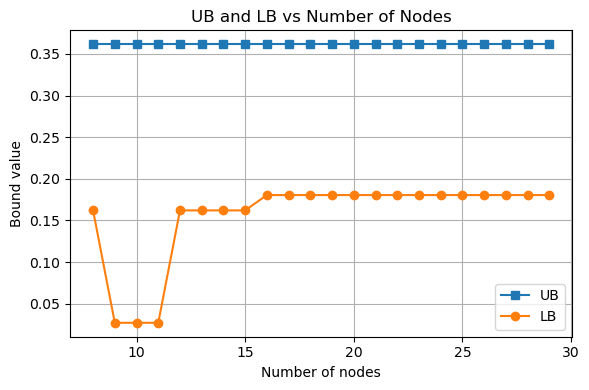

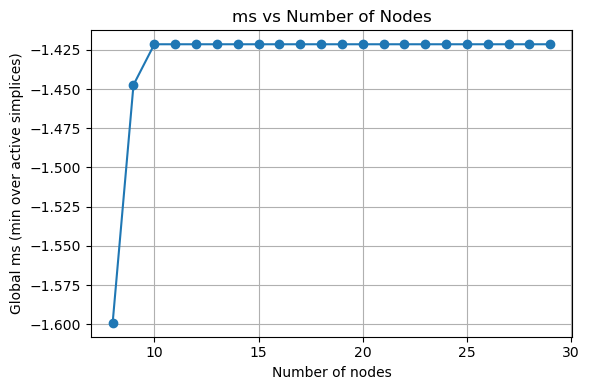

In [ ]:
x  = hist["node_count"]
LB = hist["LB_hist"]
UB = hist["UB_hist"]
ms = hist["ms_hist"]

# 图1：UB 和 LB vs number of nodes
plt.figure(figsize=(6,4))
plt.plot(x, UB, marker='s', label="UB")
plt.plot(x, LB, marker='o', label="LB")
plt.xlabel("Number of nodes")
plt.ylabel("Bound value")
plt.title("UB and LB vs Number of Nodes")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 图2：ms vs number of nodes
plt.figure(figsize=(6,4))
plt.plot(x, ms, marker='o')
plt.xlabel("Number of nodes")
plt.ylabel("Global ms (min over active simplices)")
plt.title("ms vs Number of Nodes")
plt.grid(True)
plt.tight_layout()
plt.show()
